# Goal:


* Build ML models that predict melting point in temperature units of Kelvin for organic compounds given molecular descriptors.

Columns

id : unique ID

*   id : unique ID
*   SMILES : molecular string
*  Group 1..N : descriptor features

* Tm : melting point (Kelvin) [train only]

*  **Keywords**
  * SMILES - Simplified Molecular Input Line Entry System.  


# Pre-Reqs:

In [ ]:
#When starting up
#pip install optuna catboost rdkit

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

# Data:

In [2]:
#Creating datframe from test and train csv's
TrainDataset = pd.read_csv('/content/train.csv')
TestDataset = pd.read_csv('/content/test.csv')

#Creating some additional dataframes to not be encoded
TrainNoEncDataset = pd.read_csv('/content/train.csv')
TestNoEncDataset = pd.read_csv('/content/test.csv')

In [3]:
TrainNoEncDataset.head()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
TrainDataset.info()
print("\n")
TrainDataset.describe()
print("\n")
TrainDataset.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2662 entries, 0 to 2661
Columns: 427 entries, id to Group 424
dtypes: float64(1), int64(425), object(1)
memory usage: 8.7+ MB






,0
id,0
SMILES,0
Tm,0
Group 1,0
Group 2,0
...,...
Group 420,0
Group 421,0
Group 422,0
Group 423,0


In [5]:
TestDataset.info()
print("\n")
TestDataset.describe()
print("\n")
TestDataset.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Columns: 426 entries, id to Group 424
dtypes: int64(425), object(1)
memory usage: 2.2+ MB






,0
id,0
SMILES,0
Group 1,0
Group 2,0
Group 3,0
...,...
Group 420,0
Group 421,0
Group 422,0
Group 423,0


# Data Augmentation

Augmentation was recomended by - https://pubs.rsc.org/en/content/articlelanding/2025/dd/d5dd00028a

In [6]:
from rdkit import Chem

def randomize_smiles(smiles, n=3):
    """Generate n randomized SMILES for a single molecule"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [smiles]
    return [Chem.MolToSmiles(mol, doRandom=True) for _ in range(n)]

# Print size before augmentation
print(f"Dataset before augmentation: {TrainDataset.shape[0]} rows")

# Create augmented dataset
augmented_rows = []

for idx, row in TrainDataset.iterrows():
    smi = row["SMILES"]
    randomized = randomize_smiles(smi, n=3)  # 3 extra variants
    for new_smi in randomized:
        new_row = row.copy()
        new_row["SMILES"] = new_smi
        augmented_rows.append(new_row)

# Convert list of Series to DataFrame
TrainDataset_aug = pd.DataFrame(augmented_rows)

# Combine original + augmented
TrainDataset = pd.concat([TrainDataset, TrainDataset_aug], axis=0).reset_index(drop=True)

# Print size after augmentation
print(f"Dataset after augmentation: {TrainDataset.shape[0]} rows")


Dataset before augmentation: 2662 rows
Dataset after augmentation: 10648 rows


# Data-Cleanup/Pre-Processing:

In [7]:
Features = ["SMILES"]

label_encoders = {}
for col in Features:
    le = LabelEncoder()

    # Make sure all values are strings
    TrainDataset[col] = TrainDataset[col].astype(str)
    TestDataset[col] = TestDataset[col].astype(str)

    # Fit on all unique SMILES
    all_smiles = pd.concat([TrainDataset[col], TestDataset[col]], axis=0).unique()
    le.fit(all_smiles)

    # Transform
    TrainDataset[col] = le.transform(TrainDataset[col])
    TestDataset[col] = le.transform(TestDataset[col])

    label_encoders[col] = le


In [8]:
#Re-check if datasets are fully numeric
Train_Numerical = TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Test Dataset Numerical? {Train_Numerical}")
Test_Numerical = TestDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Test Dataset Numerical? {Test_Numerical}")

/tmp/ipython-input-699104718.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Train_Numerical = TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()


Test Dataset Numerical? True
Test Dataset Numerical? True


/tmp/ipython-input-699104718.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Test_Numerical = TestDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()


In [9]:
non_numeric_cols = TrainDataset.columns[~TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all()]
print("Non-numeric columns:", non_numeric_cols.tolist())


/tmp/ipython-input-4183447977.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  non_numeric_cols = TrainDataset.columns[~TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all()]


Non-numeric columns: []


In [10]:
#Murcko Scaffold

#To help with NaN's error
TrainDataset["SMILES"] = TrainDataset["SMILES"].astype(str)

def get_scaffold(smiles):
    if pd.isna(smiles):
        return "INVALID"

    smiles = str(smiles)

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "INVALID"

    return MurckoScaffold.MurckoScaffoldSmiles(mol)

TrainDataset["scaffold"] = TrainDataset["SMILES"].apply(get_scaffold)

scaffold_to_indices = {}

for idx, scaffold in enumerate(TrainDataset["scaffold"]):
    scaffold_to_indices.setdefault(scaffold, []).append(idx)

def scaffold_kfold(scaffold_to_indices, n_splits=5, random_state=42):
    rng = np.random.RandomState(random_state)

    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)

    folds = [[] for _ in range(n_splits)]

    for i, scaffold in enumerate(scaffolds):
        folds[i % n_splits].extend(scaffold_to_indices[scaffold])

    for i in range(n_splits):
        valid_idx = np.array(folds[i])
        train_idx = np.array(
            [idx for j in range(n_splits) if j != i for idx in folds[j]]
        )
        yield train_idx, valid_idx


Streaming output truncated to the last 5000 lines.
[08:28:00] SMILES Parse Error: syntax error while parsing: 3231
[08:28:00] SMILES Parse Error: check for mistakes around position 1:
[08:28:00] 3231
[08:28:00] ^
[08:28:00] SMILES Parse Error: Failed parsing SMILES '3231' for input: '3231'
[08:28:00] SMILES Parse Error: syntax error while parsing: 1496
[08:28:00] SMILES Parse Error: check for mistakes around position 1:
[08:28:00] 1496
[08:28:00] ^
[08:28:00] SMILES Parse Error: Failed parsing SMILES '1496' for input: '1496'
[08:28:00] SMILES Parse Error: syntax error while parsing: 1469
[08:28:00] SMILES Parse Error: check for mistakes around position 1:
[08:28:00] 1469
[08:28:00] ^
[08:28:00] SMILES Parse Error: Failed parsing SMILES '1469' for input: '1469'
[08:28:00] SMILES Parse Error: syntax error while parsing: 1496
[08:28:00] SMILES Parse Error: check for mistakes around position 1:
[08:28:00] 1496
[08:28:00] ^
[08:28:00] SMILES Parse Error: Failed parsing SMILES '1496' for inp

# Data Analysis:

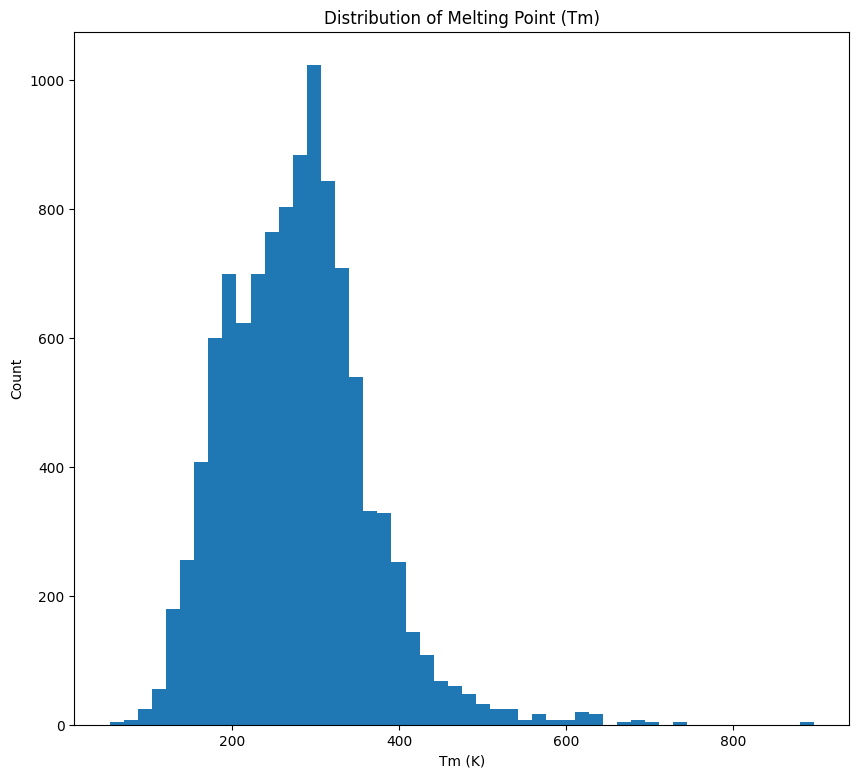


Skew measure: 0.9040492165226893

Mean: 278.2634522915102

Median: 277.3

Data is right skew


In [ ]:
#Historgram and checking skewed data
plt.rcParams['figure.figsize'] = (10, 9)

plt.hist(TrainDataset["Tm"], bins=50)
plt.title("Distribution of Melting Point (Tm)")
plt.xlabel("Tm (K)")
plt.ylabel("Count")
plt.show()


SkewMeasure = TrainDataset["Tm"].skew()
MeanSkew = TrainDataset["Tm"].mean()
MedianSkew = TrainDataset["Tm"].median()

#System to check skew
print("\nSkew measure:", SkewMeasure)
print("\nMean:", MeanSkew)
print("\nMedian:", MedianSkew)
print("")
if MeanSkew > MedianSkew:
  print("Data is right skew")
elif MeanSkew < MedianSkew:
  print("Data is left skew")
elif MeanSkew == MedianSkew:
  print("Data is symetric")

In [ ]:
missing = TrainDataset.isna().mean().sort_values(ascending=False)

print("Are there missing values?\n")

if (missing > 0).any():
    print("There are missing values!")
    print(missing[missing > 0].head(20))
else:
    print("All good, no missing values.")

Are there missing values?

All good, no missing values.


In [ ]:
#Correlation heatmap
plt.figure(figsize=(20,18))
corr = TrainDataset.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
target_corr = corr["Tm"].sort_values(ascending=False)
print(target_corr.head(10))  # top 10 features correlated with Tm
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'INVALID'

<Figure size 2000x1800 with 0 Axes>

# Model 1 - LightGBM:

In [ ]:
Target = "Tm"
IDCol = "id"

y = TrainDataset[Target]
X = TrainDataset.drop([Target, IDCol, "SMILES"], axis=1)
X_test = TestDataset.drop([IDCol, "SMILES"], axis=1)

#Ensure numeric data and fill missing values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

#Set up K-Fold ===
FOLDS = 5
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Arrays to store predictions
oof_preds = np.zeros(len(X))         # train predictions (OOF)
test_preds = np.zeros(len(X_test))   # test predictions averaged
fold_mae = []                        # store MAE for each fold

#LGBM Params
lgb_params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "metric": "mae",          # your evaluation metric
    "learning_rate": 0.03,    # slightly higher for faster training
    "num_leaves": 128,        # smaller to reduce overfitting
    "max_depth": 8,           # reasonable depth
    "n_estimators": 3000,     # enough trees with learning_rate 0.03
    "min_child_samples": 20,  # smaller to capture some small patterns
    "subsample": 0.85,        # row sampling
    "colsample_bytree": 0.75, # column sampling
    "reg_alpha": 2.0,         # L1 regularization
    "reg_lambda": 2.0,        # L2 regularization
    "random_state": 42
}

#K-Fold
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    print(f"\n=== Fold {fold+1} ===")

    # Split training and validation data
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_valid_fold, y_valid_fold = X.iloc[valid_idx], y.iloc[valid_idx]

    # Initialize model
    model = LGBMRegressor(**lgb_params)

    # Train model
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        eval_metric="mae",
        callbacks=[lgb.log_evaluation(-1)]
    )

    # Predict on validation set (OOF)
    oof_preds[valid_idx] = model.predict(X_valid_fold)

    #Predict
    test_preds += model.predict(X_test) / FOLDS

    #Mae Calc
    fold_score = mean_absolute_error(y_valid_fold, oof_preds[valid_idx])
    fold_mae.append(fold_score)
    print(f"Fold {fold+1} MAE: {fold_score:.5f}")

#Measure performance
overall_mae = mean_absolute_error(y, oof_preds)
print("\n=== Overall OOF MAE ===")
print(overall_mae)

#Submission
submission = pd.DataFrame({
    IDCol: TestDataset[IDCol],
    Target: test_preds
})

submission.to_csv("KaggleModel1LGBM.csv", index=False)
print("\nSubmission saved as KaggleModel1LGBM.csv")

# Model 2 - CatBoost Best Model ATM:

In [11]:
Target = "Tm"
IDCol = "id"

y = TrainDataset[Target]

# Base features (NO SMILES here)
X = TrainDataset.drop([Target, IDCol, "SMILES"], axis=1)
X_test = TestDataset.drop([IDCol, "SMILES"], axis=1)

#Winsorize data
winsor_cols = [
    c for c in X.columns
    if (
        X[c].dtype in [np.float64, np.float32, np.int64, np.int32]
        and not c.startswith("Group")
    )
]

LOW_Q = 0.01
HIGH_Q = 0.99

print(f"Winsorizing {len(winsor_cols)} features")

for col in winsor_cols:
    low = X[col].quantile(LOW_Q)
    high = X[col].quantile(HIGH_Q)

    X[col] = X[col].clip(lower=low, upper=high)
    X_test[col] = X_test[col].clip(lower=low, upper=high)

def rdkit_features(smiles):
    if not isinstance(smiles, str):
        return [np.nan] * 12

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 12

    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.RingCount(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.MolMR(mol),
        Descriptors.NHOHCount(mol),
        Descriptors.NOCount(mol),
    ]


rdkit_cols = [
    "MolWt", "MolLogP", "TPSA", "HDonors", "HAcceptors",
    "RingCount", "HeavyAtoms", "RotBonds", "FracCSP3",
    "MolMR", "NHOH", "NO"
]

# Train RDKit
rdkit_train = TrainDataset["SMILES"].apply(rdkit_features)
rdkit_train = pd.DataFrame(rdkit_train.tolist(), columns=rdkit_cols)

# Test RDKit
rdkit_test = TestDataset["SMILES"].apply(rdkit_features)
rdkit_test = pd.DataFrame(rdkit_test.tolist(), columns=rdkit_cols)

# Attach RDKit features
X = pd.concat([X.reset_index(drop=True), rdkit_train], axis=1)
X_test = pd.concat([X_test.reset_index(drop=True), rdkit_test], axis=1)

for col in ["MolWt", "TPSA", "MolMR"]:
    X[col] = np.log1p(X[col])
    X_test[col] = np.log1p(X_test[col])

X = X.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

group_cols = [c for c in X.columns if c.startswith("Group")]

group_sums = X[group_cols].sum(axis=0)
keep_groups = group_sums[group_sums >= 5].index

X = X.drop(columns=[c for c in group_cols if c not in keep_groups])
X_test = X_test.drop(columns=[c for c in group_cols if c not in keep_groups])

X[keep_groups] = X[keep_groups].astype("int16")
X_test[keep_groups] = X_test[keep_groups].astype("int16")

print(f"Kept {len(keep_groups)} group features out of {len(group_cols)}")
print("Final feature shape:", X.shape)

y_log = np.log1p(y)

def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 1500, 6500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "depth": trial.suggest_int("depth", 3, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 0.5, 3.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "subsample": trial.suggest_float("subsample", 0.7, 0.95),
        "min_data_in_leaf" : trial.suggest_int("min_data_in_leaf", 20, 80),
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "random_seed": 42,
        "verbose": 0
    }

    kf = KFold(n_splits=7, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))

    for train_idx, valid_idx in kf.split(X, y_log):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y_log.iloc[train_idx], y_log.iloc[valid_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=200,
            use_best_model=True
        )

        oof_preds[valid_idx] = model.predict(X_valid)

    return mean_absolute_error(y_log, oof_preds)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)

study.optimize(objective, n_trials=25)

print("\nBest CV MAE (log space):", study.best_value)
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_params = study.best_params
best_params.update({
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "random_seed": 42,
    "verbose": 0
})

final_model = CatBoostRegressor(**best_params)
final_model.fit(X, y_log)

test_preds_log = final_model.predict(X_test)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({
    IDCol: TestDataset[IDCol],
    Target: test_preds
})

submission.to_csv("KaggleModel_CatBoost_RDKit_Optuna.csv", index=False)
print("\nSubmission saved as KaggleModel_CatBoost_RDKit_Optuna.csv")


Winsorizing 0 features


Streaming output truncated to the last 5000 lines.
[08:30:09] SMILES Parse Error: check for mistakes around position 1:
[08:30:09] 3231
[08:30:09] ^
[08:30:09] SMILES Parse Error: Failed parsing SMILES '3231' for input: '3231'
[08:30:09] SMILES Parse Error: syntax error while parsing: 1496
[08:30:09] SMILES Parse Error: check for mistakes around position 1:
[08:30:09] 1496
[08:30:09] ^
[08:30:09] SMILES Parse Error: Failed parsing SMILES '1496' for input: '1496'
[08:30:09] SMILES Parse Error: syntax error while parsing: 1469
[08:30:09] SMILES Parse Error: check for mistakes around position 1:
[08:30:09] 1469
[08:30:09] ^
[08:30:09] SMILES Parse Error: Failed parsing SMILES '1469' for input: '1469'
[08:30:09] SMILES Parse Error: syntax error while parsing: 1496
[08:30:09] SMILES Parse Error: check for mistakes around position 1:
[08:30:09] 1496
[08:30:09] ^
[08:30:09] SMILES Parse Error: Failed parsing SMILES '1496' for input: '1496'
[08:30:09] SMILES Parse Error: syntax error while par

Kept 283 group features out of 424
Final feature shape: (10648, 296)


[I 2026-01-15 08:31:16,737] Trial 0 finished with value: 0.12152335290814044 and parameters: {'iterations': 2996, 'learning_rate': 0.026446626554563143, 'depth': 3, 'l2_leaf_reg': 5.210935541236994, 'random_strength': 2.3333584978749875, 'bagging_temperature': 0.7766119603763955, 'subsample': 0.739696296183355, 'min_data_in_leaf': 25}. Best is trial 0 with value: 0.12152335290814044.
[I 2026-01-15 08:32:45,550] Trial 1 finished with value: 0.11565410297046641 and parameters: {'iterations': 2309, 'learning_rate': 0.015643844474749674, 'depth': 6, 'l2_leaf_reg': 4.714386076144286, 'random_strength': 1.4940092193801946, 'bagging_temperature': 0.15493817169763802, 'subsample': 0.905210936589937, 'min_data_in_leaf': 28}. Best is trial 1 with value: 0.11565410297046641.
[I 2026-01-15 08:41:55,584] Trial 2 finished with value: 0.08598780600805635 and parameters: {'iterations': 6368, 'learning_rate': 0.010989770528432958, 'depth': 9, 'l2_leaf_reg': 2.1956485353302346, 'random_strength': 2.7927


Best CV MAE (log space): 0.07041456995647534
Best parameters:
  iterations: 4519
  learning_rate: 0.041999759718333946
  depth: 9
  l2_leaf_reg: 1.1352353400985005
  random_strength: 2.3571911214263515
  bagging_temperature: 0.8564879006227496
  subsample: 0.8251586825994377
  min_data_in_leaf: 21

Submission saved as KaggleModel_CatBoost_RDKit_Optuna.csv


# Model 3 - Ensemble:

In [ ]:
Target = "Tm"
IDCol = "id"

y = TrainDataset[Target]
X = TrainDataset.drop([Target, IDCol, "SMILES"], axis=1)
X_test = TestDataset.drop([IDCol, "SMILES"], axis=1)

# Ensure all numeric, fill missing
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

#FOLDS = 5
#kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
fold_mae = []

for fold, (train_idx, valid_idx) in enumerate(
    scaffold_kfold(scaffold_to_indices, n_splits=5)
):
    print(f"\n=== Scaffold Fold {fold+1} ===")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y_log.iloc[train_idx], y_log.iloc[valid_idx]

    model = CatBoostRegressor(**best_params)

    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=200,
        use_best_model=True
    )

    oof_preds[valid_idx] = model.predict(X_valid)

    fold_score = mean_absolute_error(y_valid, oof_preds[valid_idx])
    fold_mae.append(fold_score)

    print(f"Fold MAE (log): {fold_score:.4f}")

print("\nRandom CV MAE  :", random_cv_mae)
print("Scaffold CV MAE:", np.mean(fold_mae))


# Arrays to store OOF and test predictions
oof_preds_lgb = np.zeros(len(X))
oof_preds_cb  = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))
test_preds_cb  = np.zeros(len(X_test))

lgb_params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 128,
    "max_depth": 8,
    "n_estimators": 3000,
    "min_child_samples": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.75,
    "reg_alpha": 2,
    "reg_lambda": 2,
    "random_state": 42
}

cat_params = {
    "iterations": 2000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 3.0,
    "loss_function": "MAE",
    "random_seed": 42,
    "verbose": 0
}

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    print(f"\n=== Fold {fold+1} ===")

    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_valid_fold, y_valid_fold = X.iloc[valid_idx], y.iloc[valid_idx]

    # --- LightGBM ---
    model_lgb = LGBMRegressor(**lgb_params)
    model_lgb.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        eval_metric="mae"
    )
    oof_preds_lgb[valid_idx] = model_lgb.predict(X_valid_fold)
    test_preds_lgb += model_lgb.predict(X_test) / FOLDS

    # --- CatBoost ---
    model_cb = CatBoostRegressor(**cat_params)
    model_cb.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_valid_fold, y_valid_fold),
        early_stopping_rounds=100
    )
    oof_preds_cb[valid_idx] = model_cb.predict(X_valid_fold)
    test_preds_cb += model_cb.predict(X_test) / FOLDS

    # Fold MAE
    fold_mae_lgb = mean_absolute_error(y_valid_fold, oof_preds_lgb[valid_idx])
    fold_mae_cb  = mean_absolute_error(y_valid_fold, oof_preds_cb[valid_idx])
    print(f"Fold {fold+1} LGB MAE: {fold_mae_lgb:.5f}")
    print(f"Fold {fold+1} CatBoost MAE: {fold_mae_cb:.5f}")

X_meta_train = np.column_stack((oof_preds_lgb, oof_preds_cb))
X_meta_test  = np.column_stack((test_preds_lgb, test_preds_cb))

meta_model = LinearRegression()
meta_model.fit(X_meta_train, y)

# OOF MAE (stacked)
oof_meta_preds = meta_model.predict(X_meta_train)
overall_mae = mean_absolute_error(y, oof_meta_preds)
print("\n=== Overall OOF MAE (Stacked Ensemble) ===")
print(overall_mae)

# Predict final test set
test_meta_preds = meta_model.predict(X_meta_test)

submission = pd.DataFrame({
    IDCol: TestDataset[IDCol],
    Target: test_meta_preds
})
submission.to_csv("KaggleModel3Ensemble.csv", index=False)
print("\nSubmission saved as KaggleModel3Ensemble")



NameError: name 'scaffold_kfold' is not defined